In [1]:
import os
from glob import glob
import torch
import numpy as np
X_train = np.stack([np.loadtxt(file, dtype=np.float32) for file in glob(os.path.join("train/Inertial Signals", "*.txt"))], axis=-1)
y_train = np.loadtxt("train/y_train.txt", dtype=np.int64) - 1
X_test = np.stack([np.loadtxt(file, dtype=np.float32) for file in glob(os.path.join("test/Inertial Signals", "*.txt"))], axis=-1)
y_test = np.loadtxt("test/y_test.txt", dtype=np.int64) - 1 
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7352, 128, 9), (7352,), (2947, 128, 9), (2947,))

In [6]:
from cv import cvTrain, cvTest
from stateSpaceModel import StateSpaceModel
params = {"vocab_size": 6, "dim": 128, "N": 64, "layer": 4, "dropout": 0.2}
models = cvTrain(X_train, y_train, StateSpaceModel, params, verbose=True)
y_pred, _ = cvTest(X_test, y_test, models)

  0%|          | 0/5 [00:00<?, ?it/s]

Mean Accuracy: 0.9610


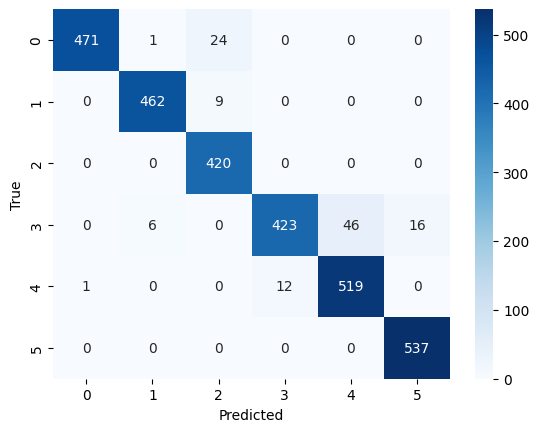

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
from torchinfo import summary
from mytorch import LSTMClassifier, Conv1dClassifier
from stateSpaceModel import StateSpaceModel
summary(StateSpaceModel(6, 64, 64, 4, 0.2), input_size=(128, 128, 9))
